In [50]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import earthaccess
import getpass
import requests
from pydap.net import create_session
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mpcrs
import cartopy.crs as ccrs
import cartopy.feature as cft
from matplotlib.colors import LinearSegmentedColormap

In [53]:
def modisaod_to_dataset(modisgranule):
    import xarray as xr
    from pyhdf.SD import SD, SDC
    hdf = SD(modisgranule, SDC.READ)

    # All of MODIS AOD data have a singular reference time - good practice to get from attribute
    modis_time_key = 'Scan_Start_Time'
    try:
        modis_time_attribute = hdf.select(modis_time_key).attributes().get('units')
        if modis_time_attribute is None:
            print("'units' attribute is not present in {modis_time_key}.")
            modis_ref_time = datetime(1993, 1, 1, 0, 0, 0)
        else:
            # Extract the date and time part
            datetime_str = modis_time_attribute.split('since ')[1].rsplit(' ', 1)[0]

            # Convert to a datetime object
            modis_ref_time = datetime.strptime(datetime_str, "%Y-%m-%d %H:%M:%S.%f")
    except Exception as e:
        # Catch and print any errors
        print(f"An error occurred: {e}")
    #  Get variables
    modis_time = hdf.select(modis_time_key)[:].ravel()
    cnts = len(modis_time)

    land_sea_flag = hdf.select('Land_sea_Flag')[:].ravel()
    aod = hdf.select('AOD_550_Dark_Target_Deep_Blue_Combined')[:].ravel() * 1e-3
    unc_land = hdf.select('Deep_Blue_Aerosol_Optical_Depth_550_Land_Estimated_Uncertainty')[:].ravel() * 1e-3
    over_land = np.logical_not(land_sea_flag == 0)
    
    data_dict = {
        'lat': (['Location'], hdf.select('Latitude')[:].ravel()),
        'lon': (['Location'], hdf.select('Longitude')[:].ravel()),
        'aod': (['Location'], aod),
        'land_sea_flag': (['Location'], land_sea_flag),
        'QC_flag': (['Location'], hdf.select('Land_Ocean_Quality_Flag')[:].ravel()),
        'sol_zen': (['Location'], hdf.select('Solar_Zenith')[:].ravel()),
        'sen_zen': (['Location'], hdf.select('Sensor_Zenith')[:].ravel()),
        'uncertainty': (['Location'], np.where(over_land, unc_land, np.add(0.05, np.multiply(0.15, aod)))),
        'obs_time': (['Location'], (modis_time + modis_ref_time.timestamp()).astype('datetime64[s]')),
    }

    coords_dict = {'Location': np.arange(cnts)}
    return xr.Dataset(data_dict, coords=coords_dict)

In [33]:
def merra2_gridcell_area(lat):
    """
    Compute MERRA-2 grid-cell area for a 0.5° x 0.625° lat-lon grid.

    Parameters
    ----------
    lat : array-like
        Latitude centers in degrees (-90 to 90, step 0.5)

    Returns
    -------
    area : ndarray
        Grid-cell area in m^2 with shape (lat,)
        (same for all longitudes at a given latitude)
    """
    R = 6_371_000.0  # Earth radius [m]

    dlat = np.deg2rad(0.5)
    dlon = np.deg2rad(0.625)

    lat_rad = np.deg2rad(lat)

    area = (
        R**2
        * dlon
        * (np.sin(lat_rad + dlat / 2) - np.sin(lat_rad - dlat / 2))
    )

    return area

In [34]:
tags_dict = {
    'extinction': 'M2T1NXAER',
    'emission': 'M2T1NXADG',
}
projection = ccrs.PlateCarree()

# auth = earthaccess.login()

In [57]:
results = earthaccess.search_data(short_name=tags_dict['extinction'], temporal=('2024-10-15', '2024-11-30'))
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/47 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/47 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/47 [00:00<?, ?it/s]

In [58]:
ds = xr.open_dataset(files[0])

In [60]:
ds

<xarray.Dataset> Size: 998MB
Dimensions:    (time: 24, lat: 361, lon: 576)
Coordinates:
  * time       (time) datetime64[ns] 192B 2024-10-15T00:30:00 ... 2024-10-15T...
  * lat        (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon        (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
Data variables: (12/50)
    BCANGSTR   (time, lat, lon) float32 20MB ...
    BCCMASS    (time, lat, lon) float32 20MB ...
    BCEXTTAU   (time, lat, lon) float32 20MB ...
    BCFLUXU    (time, lat, lon) float32 20MB ...
    BCFLUXV    (time, lat, lon) float32 20MB ...
    BCSCATAU   (time, lat, lon) float32 20MB ...
    ...         ...
    SUFLUXU    (time, lat, lon) float32 20MB ...
    SUFLUXV    (time, lat, lon) float32 20MB ...
    SUSCATAU   (time, lat, lon) float32 20MB ...
    TOTANGSTR  (time, lat, lon) float32 20MB ...
    TOTEXTTAU  (time, lat, lon) float32 20MB ...
    TOTSCATAU  (time, lat, lon) float32 20MB ...
Attributes: (12/30)
    History:                           Original file generated: Fri Oct 25 20...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Filename:                          MERRA2_400.tavg1_2d_aer_Nx.20241015.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/KLICLTZ8EM9D
    RangeBeginningDate:                2024-10-15
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2024-10-15
    RangeEndingTime:                   23:59:59.000000

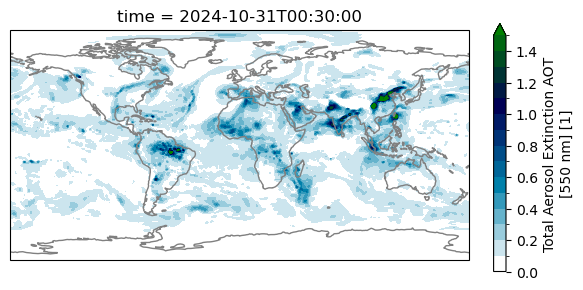

In [91]:
fig, ax = plt.subplots(subplot_kw=dict(projection=projection))
ds['TOTEXTTAU'].isel(time=0).plot.contourf(
    ax=ax,
    levels=np.arange(0, 1.6, 0.1),
    cmap='ocean_r',
    cbar_kwargs={'fraction':0.025}
)
ax.coastlines(color='grey')

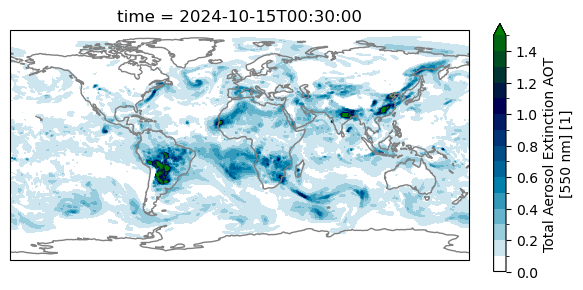

In [87]:
fig, ax = plt.subplots(subplot_kw=dict(projection=projection))
ds['TOTEXTTAU'].isel(time=0).plot.contourf(
    ax=ax,
    levels=np.arange(0, 1.6, 0.1),
    cmap='ocean_r',
    cbar_kwargs={'fraction':0.025}
)
ax.coastlines(color='grey')

In [7]:
def global_emission(ds, varlist):
    m2area = merra2_gridcell_area(ds.lat.values)
    area_2d = m2area[:, None]
    df = pd.DataFrame({'time': ds.time.values})
    for var in varlist:
        df[var] = (ds[var] * area_2d).sum(dim=('lat', 'lon')).values
    return df
    
def global_average(ds, varlist):
    df = pd.DataFrame({'time': ds.time.values})
    for var in varlist:
        df[var] = ds[var].mean(dim=('lat', 'lon')).values
    return df

In [ ]:
ts_df = pd.DataFrame()
for file in files:
    print(f'Processing {file}')
    tmpds = xr.open_dataset(file)
    # tmpdf = global_emission(tmpds, ['BCEMBB', 'OCEMBB'])
    tmpdf = global_average(tmpds, ['SUEXTTAU'])
    ts_df = pd.concat((ts_df, tmpdf))

ts_df = ts_df.set_index('time')

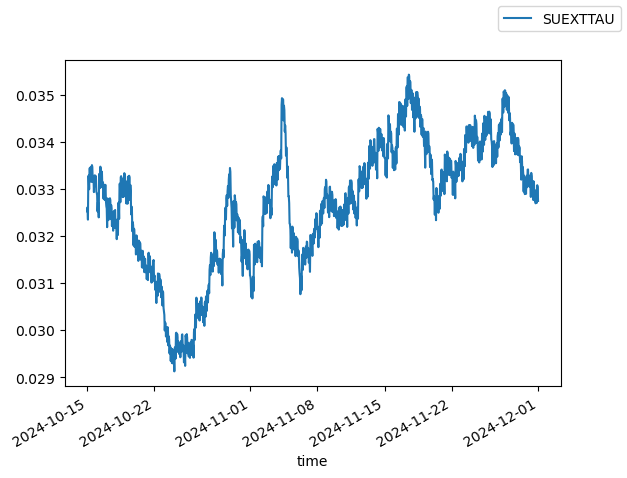

In [64]:
fig, ax = plt.subplots(
    # subplot_kw={'figsize': (10, 5)}
)

cols = ts_df.columns
ax = ts_df['SUEXTTAU'].plot(ax=ax)    
# ax2 = ts_df['BCEMBB'].plot(ax=ax, secondary_y=True)

fig.legend()


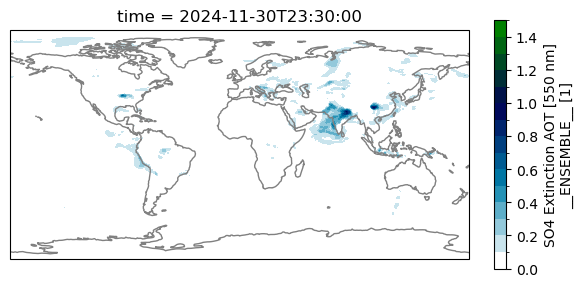

In [66]:
fig, ax = plt.subplots(subplot_kw=dict(projection=projection))
tmpds['SUEXTTAU'].isel(time=23).plot.contourf(
    ax=ax,
    levels=np.arange(0, 1.6, 0.1),
    cmap='ocean_r',
    cbar_kwargs={'fraction':0.025}
)
ax.coastlines(color='grey')

In [25]:
tmpdf['EMBB'] = ts_df['BCEMBB'] + ts_df['OCEMBB']

In [29]:
totaldf = pd.DataFrame()
totaldf['EMBB'] = ts_df['BCEMBB'] + ts_df['OCEMBB']

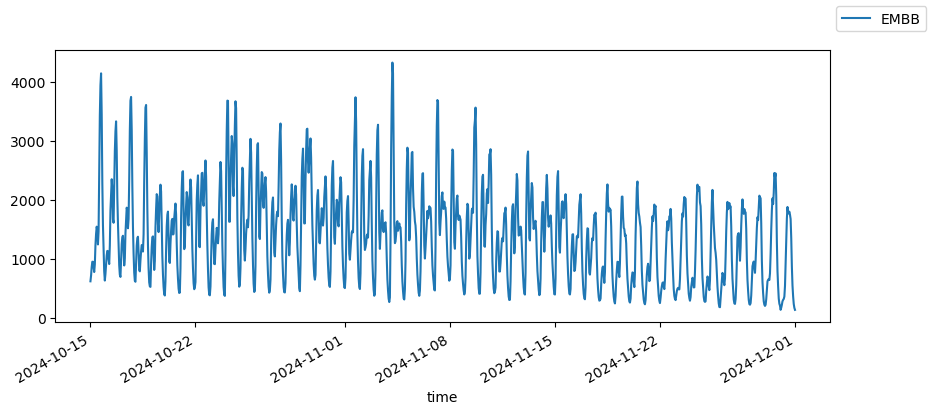

In [31]:
fig, ax = plt.subplots()
ax = (totaldf['EMBB']).plot(figsize=(10, 4))
fig.legend()

In [37]:
all_dataset_list = earthaccess.search_datasets(count=-1)

A valid set of parameters is needed to search for datasets on CMR


In [44]:
results = earthaccess.search_data(short_name='MYD04_L2', temporal=('2024-10-15', '2024-10-15'))

In [45]:
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/156 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/156 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/156 [00:00<?, ?it/s]